In [2]:
import random
from collections import Counter
import copy
import json
from datetime import datetime


## Initialize chromosome parameters (slots per day)


In [3]:
# Constants
UNIT_MINUTES = 5
DAY_START = 8 * 60  # 08:00 in minutes
DAY_END = 19 * 60   # 19:00 in minutes
NUM_SLOTS = (DAY_END - DAY_START) // UNIT_MINUTES  # 108 slots


## Input of the algorithm


following is dummy data to see how is the structure of the data the model is actually working with


we need a dictionary for prefilled sessions


In [4]:
# Fixed tasks (already scheduled)
fixed_tasks = [
    {"title": "analyse", "start": 6, "duration": 18},    # 08:30 – 10:00
    {"title": "c++", "start": 24, "duration": 18},       # 10:00 – 11:30
    {"title": "group project", "start": 66, "duration": 18},  # 13:30 – 15:00
    {"title": "machine learning", "start": 84, "duration": 18}   # 15:00 – 16:30
]


and another dictionary for the tasks to be scheduled


In [5]:
# Tasks to schedule
tasks_to_schedule = [
    {"id": "T1", "duration": 6, "category": 'School', "priority": 1},
    {"id": "T2", "duration": 4, "category": 'Hobby', "priority": 2},
    {"id": "T3", "duration": 8, "category": 'Sport', "priority": 3},
    {"id": "T4", "duration": 2, "category": 'Hobby', "priority": 1},
    {"id": "T5", "duration": 3, "category": 'Sport', "priority": 2},
    {"id": "T6", "duration": 6, "category": 'School', "priority": 3},
    {"id": "T7", "duration": 6, "category": 'School', "priority": 2},
]

### override the lists of tasks with real data


from ENSIA Year 3 G7 students timetable in addition to some tasks to be scheduled


In [6]:
fixed_tasks_path = 'data/G7/formatted_fixed_tasks.json'
to_schedule_path = 'data/G7/formatted_tasks_to_schedule.json'
fixed_task_week = None
tasks_to_schedule_week = None
with open(fixed_tasks_path) as f:
    fixed_task_week = json.load(f)
with open(to_schedule_path) as f:
    tasks_to_schedule_week = json.load(f)


In [7]:
today_date = datetime.strptime('2025-05-08T08:00:00', '%Y-%m-%dT%H:%M:%S').date()
# print(today_date)
today_fixed_tasks = []
today_to_schedule_tasks = []
for fixed_task in fixed_task_week:
    fixed_task_date = datetime.strptime(fixed_task["deadline"], '%Y-%m-%dT%H:%M:%S').date()
    if fixed_task_date == today_date:
        today_fixed_tasks.append(fixed_task)
    
for to_schedule_task in tasks_to_schedule_week:
    to_schedule_task_date = datetime.strptime(to_schedule_task["deadline"], '%Y-%m-%dT%H:%M:%S').date()
    # print(to_schedule_task_date, today_date)
    if to_schedule_task_date == today_date:
        today_to_schedule_tasks.append(to_schedule_task)
    
    
    
       
print(len(today_fixed_tasks), len(today_to_schedule_tasks))
    

2 9


In [259]:
fixed_tasks= today_fixed_tasks
tasks_to_schedule = today_to_schedule_tasks


In [9]:
print(fixed_tasks,tasks_to_schedule)

[{'title': 'analyse', 'start': 6, 'duration': 18}, {'title': 'c++', 'start': 24, 'duration': 18}, {'title': 'group project', 'start': 66, 'duration': 18}, {'title': 'machine learning', 'start': 84, 'duration': 18}] [{'id': 'T1', 'duration': 6, 'category': 'School', 'priority': 1}, {'id': 'T2', 'duration': 4, 'category': 'Hobby', 'priority': 2}, {'id': 'T3', 'duration': 8, 'category': 'Sport', 'priority': 3}, {'id': 'T4', 'duration': 2, 'category': 'Hobby', 'priority': 1}, {'id': 'T5', 'duration': 3, 'category': 'Sport', 'priority': 2}, {'id': 'T6', 'duration': 6, 'category': 'School', 'priority': 3}, {'id': 'T7', 'duration': 6, 'category': 'School', 'priority': 2}]


create a schedule datastructure to store the list of tasks


In [261]:
# Fixed schedule in slot form
fixed_schedule = [""] * NUM_SLOTS
for task in fixed_tasks:
    for i in range(task["start"], task["start"] + task["duration"]):
        fixed_schedule[i] = task["title"]


## Definition of the chromosome


from a fixed schedule and a list of tasks, we create a chromosome
which basically is any valid schedule(we start with random assignment)


In [262]:
# Generate an individual (chromosome)
def assign_task(chromo, task, fixed_schedule):
    possible_starts = list(range(NUM_SLOTS - task["duration"] + 1))
    random.shuffle(possible_starts)
    for start in possible_starts:
        block = chromo[start:start + task["duration"]]
        fixed_block = fixed_schedule[start:start + task["duration"]]
        if all(slot is None for slot in block) and all(f == "" for f in fixed_block):
            for i in range(task["duration"]):
                chromo[start + i] = {
                    "task_id": task["title"],
                    "category": task["category"],
                    "priority": task["priority"]
                }
            return True
    return False


In [263]:

def generate_chromosome(tasks, fixed_schedule):
    chromo = [None for _ in range(NUM_SLOTS)]
    for task in tasks:
        success = assign_task(chromo, task, fixed_schedule)
        if not success:
            return None
    return chromo


## Fitness function


In [264]:

# Count occurrences of task IDs
def count_task_occurrences(chromo):
    counter = Counter()
    for slot in chromo:
        if slot:
            counter[slot["task_id"]] += 1
    return counter

# Check repeated categories in nearby slots
def category_penalty(chromo):
    penalty = 0
    for i in range(NUM_SLOTS - 1):
        if chromo[i] and chromo[i + 1]:
            if chromo[i]["category"] == chromo[i + 1]["category"]:
                penalty += 5
    return penalty

# Fitness evaluation
def fitness(chromo, tasks, fixed_schedule):
    if chromo is None:
        return -10000
    score = 0
    task_counts = count_task_occurrences(chromo)
    for task in tasks:
        assigned = task_counts.get(task["id"], 0)
        diff = abs(assigned - task["duration"])
        if assigned == task["duration"]:
            score += assigned * 10
        else:
            score -= diff * 10

    # Overlap penalty
    for i, slot in enumerate(chromo):
        if slot and fixed_schedule[i] != "":
            score -= 100

    # Category repetition
    score -= category_penalty(chromo)
    
     # Priority penalty: later slots shouldn't have higher priority than earlier ones
    for i in range(len(chromo) - 1):
        current = chromo[i]
        next_one = chromo[i + 1]
        if current and next_one:
            if current["task_id"] != next_one["task_id"] and current["priority"] < next_one["priority"]:
                score -= 20  # Penalize priority inversion

    return score

In [ ]:

# Mutation: randomly reassign some slots
def mutate(chromo, tasks, fixed_schedule, rate=0.2):
    chromo = copy.deepcopy(chromo)
    for task in tasks:
        if random.random() < rate:
            # Remove current slots
            for i in range(NUM_SLOTS):
                if chromo[i] and chromo[i]["task_id"] == task["id"]:
                    chromo[i] = None
            assign_task(chromo, task, fixed_schedule)
    return chromo

# Crossover operation
def crossover(p1, p2):
    split = random.randint(1, NUM_SLOTS - 2)
    child = p1[:split] + p2[split:]
    return child

# selection operation
def select(pop, tasks, fixed_schedule, k=5):
    selected = random.sample(pop, k)
    return max(selected, key=lambda c: fitness(c, tasks, fixed_schedule))

# Print readable schedule
def print_schedule(chromo):
    print("\nFinal Schedule:")
    for i in range(NUM_SLOTS):
        time = DAY_START + i * UNIT_MINUTES
        hour = time // 60
        minute = time % 60
        fixed = fixed_schedule[i]
        dynamic = chromo[i]["task_id"] if chromo[i] else ""
        label = fixed if fixed else (dynamic if dynamic else "Free")
        print(f"{hour:02d}:{minute:02d} - {label}")


function for visualization the evolution of the model


In [266]:
import matplotlib.pyplot as plt

def plot_fitness_evolution(fitness_history):
    plt.figure(figsize=(10, 5))
    plt.plot(fitness_history, marker='o', color='blue')
    plt.title('Fitness Evolution Over Generations')
    plt.xlabel('Generation')
    plt.ylabel('Best Fitness Score')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Testing the algorithm


In [273]:
# --- GA Parameters ---
POP_SIZE = 20
GENERATIONS = 100
MUTATION_RATE = 0.3
NO_IMPROVEMENT_LIMIT = 20

## GA operations


In [268]:
# Run GA
population = []
fitness_history = []
while len(population) < POP_SIZE:
    chromo = generate_chromosome(tasks_to_schedule, fixed_schedule)
    if chromo:
        population.append(chromo)



 Stopped at generation 20 (no improvement)


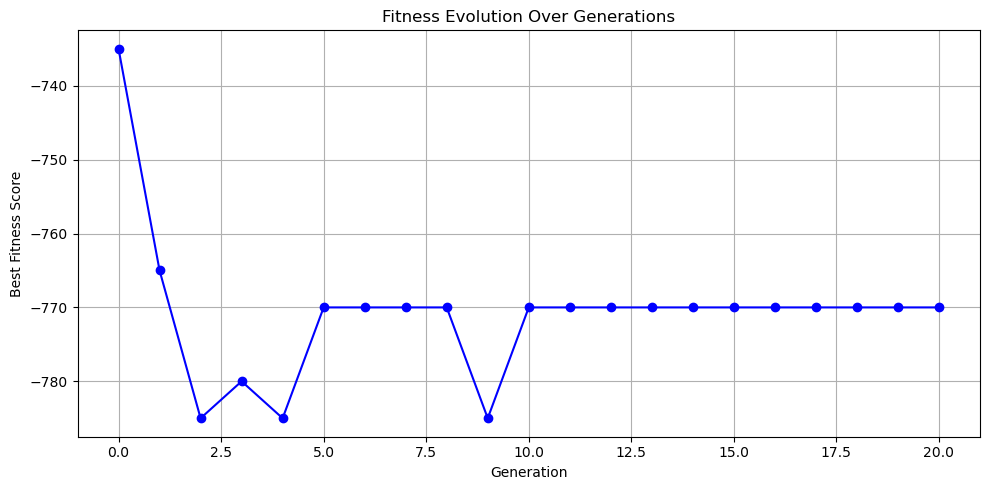


 Best fitness after 21 generations: -735

Final Schedule:
08:00 - Free
08:05 - Make Smoothie
08:10 - Make Smoothie
08:15 - Make Smoothie
08:20 - Free
08:25 - Free
08:30 - Free
08:35 - Sketch Nature Scene
08:40 - Sketch Nature Scene
08:45 - Sketch Nature Scene
08:50 - Sketch Nature Scene
08:55 - Free
09:00 - Free
09:05 - Free
09:10 - Free
09:15 - Free
09:20 - Free
09:25 - Free
09:30 - Free
09:35 - Walk the Dog
09:40 - Walk the Dog
09:45 - Walk the Dog
09:50 - Walk the Dog
09:55 - Walk the Dog
10:00 - Walk the Dog
10:05 - Free
10:10 - Project Management - Lecture
10:15 - Project Management - Lecture
10:20 - Project Management - Lecture
10:25 - Project Management - Lecture
10:30 - Project Management - Lecture
10:35 - Project Management - Lecture
10:40 - Project Management - Lecture
10:45 - Project Management - Lecture
10:50 - Project Management - Lecture
10:55 - Project Management - Lecture
11:00 - Project Management - Lecture
11:05 - Project Management - Lecture
11:10 - Project Manageme

In [269]:
best_fitness = float('-inf')
best_solution = None
no_improvement = 0

for generation in range(GENERATIONS):
    # print(f"starting with generation {generation}")
    population.sort(key=lambda c: fitness(c, tasks_to_schedule, fixed_schedule), reverse=True)
    current_best = fitness(population[0], tasks_to_schedule, fixed_schedule)
    fitness_history.append(current_best)  # Always record fitness

    if current_best > best_fitness:
        best_fitness = current_best
        best_solution = population[0]

        no_improvement = 0
    else:
        no_improvement += 1
        if no_improvement >= NO_IMPROVEMENT_LIMIT:
            print(f"\n Stopped at generation {generation} (no improvement)")
            break

    next_gen = []
    while len(next_gen) < POP_SIZE:
        parent1 = select(population, tasks_to_schedule, fixed_schedule)
        parent2 = select(population, tasks_to_schedule, fixed_schedule)
        child = crossover(parent1, parent2)
        child = mutate(child, tasks_to_schedule, fixed_schedule, rate=MUTATION_RATE)
        next_gen.append(child)

    population = next_gen
    
    

plot_fitness_evolution(fitness_history)


# --- Final Output ---
print(f"\n Best fitness after {generation+1} generations: {best_fitness}")
print_schedule(best_solution)


## Visualize the generated schedule


In [270]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timedelta

def plot_schedule_timeline(chromo, fixed_schedule):
    timeline = [slot["task_id"] if slot else fixed_schedule[i] for i, slot in enumerate(chromo)]
    
    task_color = {}
    colors = plt.cm.get_cmap('tab20', len(set(filter(None, timeline))))
    fig, ax = plt.subplots(figsize=(15, 2))

    y = 0
    current_task = None
    start = 0
    UNIT = UNIT_MINUTES  # e.g., 15
    START_TIME = datetime.strptime("08:00", "%H:%M")

    def draw_block(task_id, start_slot, end_slot):
        if task_id not in task_color:
            task_color[task_id] = colors(len(task_color))
        start_minute = start_slot * UNIT
        duration = (end_slot - start_slot) * UNIT
        ax.broken_barh([(start_minute, duration)],
                       (y, 1),
                       facecolors=task_color[task_id])

        # Add task label centered
        mid = start_minute + duration / 2
        ax.text(mid, y + 0.5, task_id, ha='center', va='center', fontsize=8, color='white')

        # Add time labels at start and end
        start_time_str = (START_TIME + timedelta(minutes=start_minute)).strftime("%H:%M")
        end_time_str = (START_TIME + timedelta(minutes=start_minute + duration)).strftime("%H:%M")

        ax.text(start_minute, y + 1.2, start_time_str, ha='center', va='bottom', fontsize=7, rotation=45)
        ax.text(start_minute + duration, y + 1.2, end_time_str, ha='center', va='bottom', fontsize=7, rotation=45)

    for i, task_id in enumerate(timeline + [None]):
        if task_id != current_task:
            if current_task:
                draw_block(current_task, start, i)
            current_task = task_id
            start = i

    ax.set_xlim(0, NUM_SLOTS * UNIT)
    ax.set_ylim(0, 3)
    ax.set_yticks([])
    ax.set_xlabel('Time')
    ax.set_title("Task Schedule Timeline (Start/End Times Only)")
    plt.tight_layout()
    plt.show()


C:\Users\Bilal\AppData\Local\Temp\ipykernel_9016\2844876732.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(set(filter(None, timeline))))


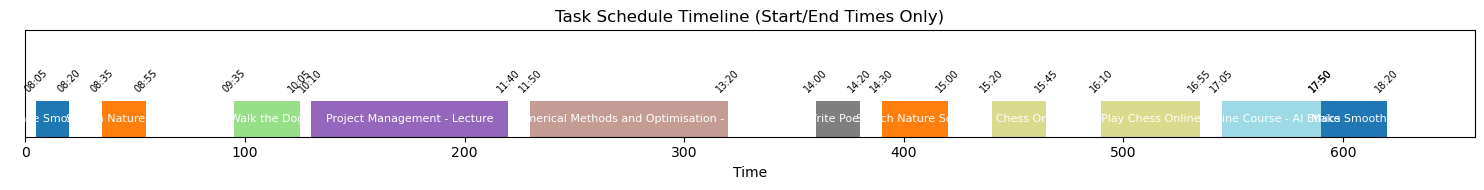

In [271]:
plot_schedule_timeline(best_solution, fixed_schedule)
